# 🚢 Titanic Dataset - Exploratory Data Analysis

> **Goal:** Understand which passengers survived and why — using feature engineering, clean visualizations, and insights.

---

## 📋 Table of Contents
1. [Setup & Imports](#1-setup)
2. [Load Data](#2-load-data)
3. [EDA Report](#3-eda-report)
4. [Feature Engineering](#4-feature-engineering)
5. [Univariate Analysis](#5-univariate)
6. [Bivariate Analysis](#6-bivariate)
7. [Multivariate Analysis](#7-multivariate)
8. [Data Cleaning — Missing Value Comparison](#8-data-cleaning)

## 1. Setup & Imports <a id='1-setup'></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Data <a id='2-load-data'></a>

In [2]:
df   = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

train_test = pd.concat([df, test], ignore_index=True)

print(f'Train shape : {df.shape}')
print(f'Test shape  : {test.shape}')
print(f'Combined    : {train_test.shape}')
df.head()

Train shape : (891, 12)
Test shape  : (418, 11)
Combined    : (1309, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. EDA Report <a id='3-eda-report'></a>

In [3]:
def eda_report(df):

    print('='*60)
    print('DATASET SHAPE')
    print(df.shape)

    print('\n'+'='*60)
    print('DUPLICATES')
    print(df.duplicated().sum())
    
    print('\n' + '='*60)
    print('DATA TYPES')
    display(df.dtypes)

    print('\n' + '='*60)
    print('UNIQUE VALUES')
    display(df.nunique())

    
    print('\n'+'='*60)
    print('MISSING VALUES')
    display(
        pd.DataFrame({
            'Null Count':df.isnull().sum(),
            'Null %':round(df.isnull().mean()*100,2)
        }).sort_values('Null %',ascending=False)
    )

    print('\n'+'='*60)
    print('NUMERICAL SUMMARY')
    display(df.describe())

    print('\n'+'='*60)
    print('CATEGORICAL SUMMARY')
    display(df.describe(include='object'))

In [44]:
eda_report(df)

DATASET SHAPE
(891, 12)

DUPLICATES
0

DATA TYPES


PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


UNIQUE VALUES


PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64


MISSING VALUES


,Null Count,Null %
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Survived,0,0.00
Pclass,0,0.00
Name,0,0.00
Sex,0,0.00
SibSp,0,0.00
Parch,0,0.00



NUMERICAL SUMMARY


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



CATEGORICAL SUMMARY


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


## summary
- 1. Missing values in Age,Cabin,Embarked Columns
- 2. More Than 77.10 % value are missing in cabin column,so will have to drop
- 3. Few columns have inappropriate data type
- 4. in age column there is flot values 
- 5. categorical columns = survived,PClass,sex,SibSp,Parch,Embarked
-    Numerical columns = Age,Fare,PassengerId
-    Mixed columns = Name,Ticket,Cabin

In [5]:
549/891*100 # notSurvived out of 891

61.61616161616161

## 4. Feature Engineering <a id='4-feature-engineering'></a>

In [6]:
def eda_report(train_test):

    print('='*60)
    print('DATASET SHAPE')
    print(train_test.shape)

    print('\n'+'='*60)
    print('DUPLICATES')
    print(train_test.duplicated().sum())
    
    print('\n' + '='*60)
    print('DATA TYPES')
    display(train_test.dtypes)

    print('\n' + '='*60)
    print('UNIQUE VALUES')
    display(train_test.nunique())

    
    print('\n'+'='*60)
    print('MISSING VALUES')
    display(
        pd.DataFrame({
            'Null Count':train_test.isnull().sum(),
            'Null %':round(df.isnull().mean()*100,2)
        }).sort_values('Null %',ascending=False)
    )

    print('\n'+'='*60)
    print('NUMERICAL SUMMARY')
    display(train_test.describe())

    print('\n'+'='*60)
    print('CATEGORICAL SUMMARY')
    display(train_test.describe(include='object'))

In [7]:
eda_report(train_test)

DATASET SHAPE
(1309, 12)

DUPLICATES
0

DATA TYPES


PassengerId      int64
Survived       float64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


UNIQUE VALUES


PassengerId    1309
Survived          2
Pclass            3
Name           1307
Sex               2
Age              98
SibSp             7
Parch             8
Ticket          929
Fare            281
Cabin           186
Embarked          3
dtype: int64


MISSING VALUES


,Null Count,Null %
Cabin,1014,77.10
Age,263,19.87
Embarked,2,0.22
PassengerId,0,0.00
Survived,418,0.00
Pclass,0,0.00
Name,0,0.00
Sex,0,0.00
SibSp,0,0.00
Parch,0,0.00



NUMERICAL SUMMARY


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,1309.000000,891.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000
mean,655.000000,0.383838,2.294882,29.881138,0.498854,0.385027,33.295479
std,378.020061,0.486592,0.837836,14.413493,1.041658,0.865560,51.758668
min,1.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,328.000000,0.000000,2.000000,21.000000,0.000000,0.000000,7.895800
50%,655.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,982.000000,1.000000,3.000000,39.000000,1.000000,0.000000,31.275000
max,1309.000000,1.000000,3.000000,80.000000,8.000000,9.000000,512.329200



CATEGORICAL SUMMARY


,Name,Sex,Ticket,Cabin,Embarked
count,1309,1309,1309,295,1307
unique,1307,2,929,186,3
top,"Connolly, Miss. Kate",male,CA. 2343,C23 C25 C27,S
freq,2,843,11,6,914


In [8]:
# ── Family features ───────────────────────────────────────────────────────────
train_test['FamilySize'] = train_test['SibSp'] + train_test['Parch'] + 1

train_test['FamilyType'] = np.where(
    train_test['FamilySize'] == 1, 'Alone',
    np.where(train_test['FamilySize'] == 2, 'Double',
    np.where(train_test['FamilySize'] < 5, 'Small', 'Large')) 
)

# ── Fare per person ───────────────────────────────────────────────────────────
train_test['FarePerPerson'] = (train_test['Fare'] / train_test['FamilySize']).round(2)

# ── Name derived features ────────────────────────────────────────────────────
train_test['NameTitle']  = train_test['Name'].str.extract(r' ([A-Za-z]+)\.')
train_test['Surname']    = train_test['Name'].str.split(',').str[0]
train_test['FamilyGroup']= train_test['Surname'] + '_' + train_test['Ticket'].astype(str)

# ── Ticket group size ─────────────────────────────────────────────────────────
train_test['TicketGroupSize'] = train_test.groupby('Ticket')['Ticket'].transform('count')

# ── Age group ────────────────────────────────────────────────────────────────
bins   = [0, 2, 12, 19, 30, 60, 100]
labels = ['Infant', 'Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
train_test['Age_Group'] = pd.cut(
    train_test['Age'], bins=bins, labels=labels, right=True
)

print(f'✅ {len(["FamilySize","FamilyType","FarePerPerson","NameTitle","Surname","FamilyGroup","TicketGroupSize","Age_Group"])} new features added')
train_test[['Name','FamilySize','FamilyType','FarePerPerson','NameTitle','Surname','FamilyGroup','TicketGroupSize','Age_Group']].head(8)

✅ 8 new features added


,Name,FamilySize,FamilyType,FarePerPerson,NameTitle,Surname,FamilyGroup,TicketGroupSize,Age_Group
0,"Braund, Mr. Owen Harris",2,Double,3.62,Mr,Braund,Braund_A/5 21171,1,Young Adult
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",2,Double,35.64,Mrs,Cumings,Cumings_PC 17599,2,Adult
2,"Heikkinen, Miss. Laina",1,Alone,7.92,Miss,Heikkinen,Heikkinen_STON/O2. 3101282,1,Young Adult
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",2,Double,26.55,Mrs,Futrelle,Futrelle_113803,2,Adult
4,"Allen, Mr. William Henry",1,Alone,8.05,Mr,Allen,Allen_373450,1,Adult
5,"Moran, Mr. James",1,Alone,8.46,Mr,Moran,Moran_330877,1,NaN
6,"McCarthy, Mr. Timothy J",1,Alone,51.86,Mr,McCarthy,McCarthy_17463,2,Adult
7,"Palsson, Master. Gosta Leonard",5,Large,4.22,Master,Palsson,Palsson_349909,5,Infant


---
## ✅ Feature Engineering — Conclusion

8 new features were created from existing columns to improve analytical depth:

| Feature | Derived From | Purpose |
|---------|-------------|---------|
| `FamilySize` | SibSp + Parch + 1 | Total people travelling together |
| `FamilyType` | FamilySize | Categorizes: Alone / Double / Small / Large |
| `FarePerPerson` | Fare ÷ FamilySize | Normalizes fare across group sizes |
| `NameTitle` | Name (regex) | Extracts social title (Mr, Mrs, Miss, Dr…) |
| `Surname` | Name (split) | Enables family-level survival analysis |
| `FamilyGroup` | Surname + Ticket | Unique family identifier on board |
| `TicketGroupSize` | Ticket (groupby count) | How many passengers shared a ticket |
| `Age_Group` | Age (binning) | Infant / Child / Teen / Young Adult / Adult / Senior |

### 🔍 Key Insights from Feature Engineering
- **FamilyType** simplifies family size into meaningful survival-relevant buckets
- **FarePerPerson** is more fair than raw Fare for comparing individual spending across group bookings
- **NameTitle** captures social status (e.g., "Master" = young male, "Dr"/"Col" = high status)
- **Age_Group** converts continuous age into interpretable categories aligned with evacuation priorities
- **TicketGroupSize** independently captures group travel without relying only on family relations



## Visualizations:

In [9]:
#doing bivariate ,univariate,and multivariate on new columns in train_test dataset

## 5. Univariate Analysis <a id='5-univariate'></a>

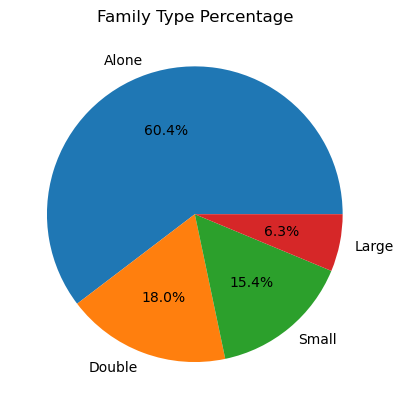

In [10]:
train_test["FamilyType"].value_counts().plot(kind="pie",autopct="%1.1f%%")

plt.title("Family Type Percentage")

plt.ylabel("")

plt.show()

### 📝 Conclusion — Family Type Distribution (Pie Chart)
The majority of passengers (~60%) traveled **alone**, making "Alone" the dominant group. Only a small fraction traveled in large families (5+ members). This indicates Titanic passengers were predominantly solo travelers or couples, which has significant implications for survival — as we'll see, traveling alone was associated with lower survival rates.

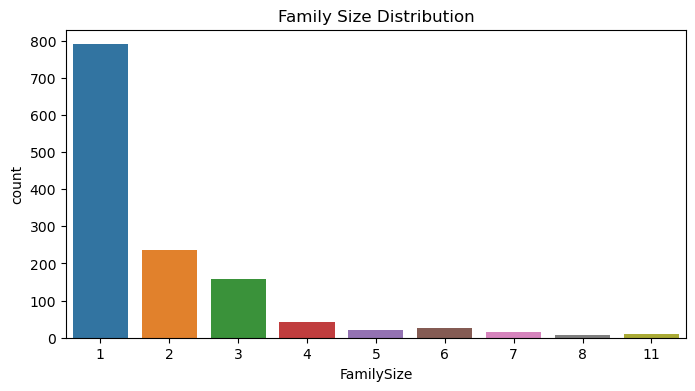

In [11]:
plt.figure(figsize=(8,4))
sns.countplot(x='FamilySize', data=train_test)
plt.title('Family Size Distribution')
plt.show()

### 📝 Conclusion — Family Size Distribution (Count Plot)
Family size **1 (solo travelers)** dominates by far, followed by small family sizes of 2 and 3. Very few passengers had family sizes above 5. This right-skewed distribution confirms that most passengers had minimal family accompaniment, and large family groups were rare on board.

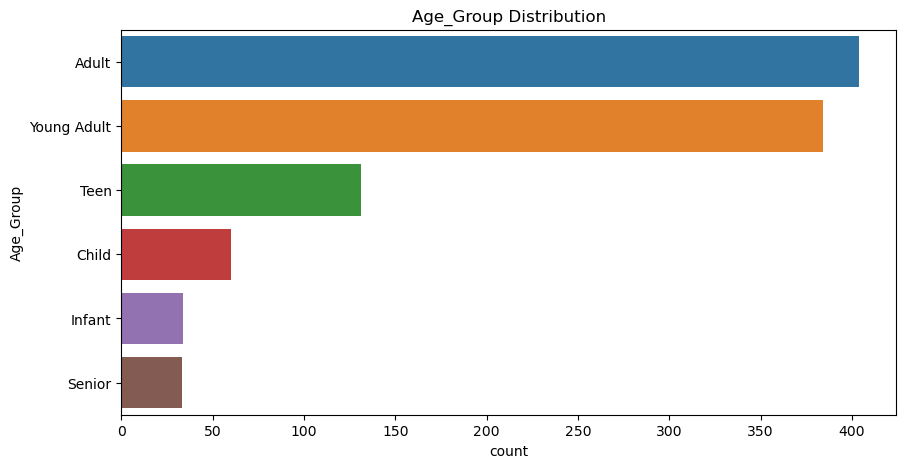

In [12]:
plt.figure(figsize=(10,5))
sns.countplot(
    y='Age_Group',
    data=train_test,
    order=train_test['Age_Group'].value_counts().index
)
plt.title('Age_Group Distribution')
plt.show()

### 📝 Conclusion — Age Group Distribution (Count Plot)
**Adults (ages 30–60)** made up the largest chunk of passengers, followed by **Young Adults (ages 19–30)**. Infants and Seniors were the rarest groups. Teens and Children formed a small but meaningful portion. The passenger base was predominantly working-age adults — likely emigrants, professionals, and leisure travelers.

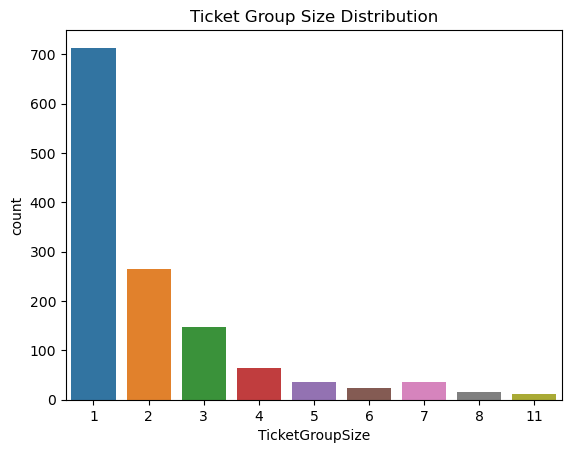

In [13]:
sns.countplot(
    x='TicketGroupSize',
    data=train_test
)

plt.title('Ticket Group Size Distribution')
plt.show()

### 📝 Conclusion — Ticket Group Size Distribution (Count Plot)
Most passengers had a **ticket group size of 1** (sole ticket holder), while groups of 2–4 were the next common. Very large ticket groups (7+) are rare. This largely mirrors the family size distribution and confirms that traveling in small groups was the norm aboard the Titanic.

---
## ✅ Univariate Analysis — Conclusion

The univariate analysis explored the standalone distribution of four key engineered features:

| Feature | Dominant Category | Key Observation |
|---------|------------------|----------------|
| `FamilyType` | Alone (~60%) | Most passengers had no family on board |
| `FamilySize` | 1 (solo) | Heavily right-skewed; small groups rare |
| `Age_Group` | Adult (30–60) | Typical working-age traveler demographics |
| `TicketGroupSize` | 1 | Most passengers held individual tickets |

### 🔍 Key Insights
- The **solo traveler** profile dominates all family-related features — both FamilyType and FamilySize confirm this
- **Adults and Young Adults** form the bulk of passengers; children and seniors are minorities
- **Ticket group sizes** largely mirror family size, suggesting most ticket-sharing was within families
- These skewed distributions mean any model trained on this data must handle **class imbalance carefully** (especially for rare groups like Infants and Large families)


## 6. Bivariate Analysis <a id='6-bivariate'></a>

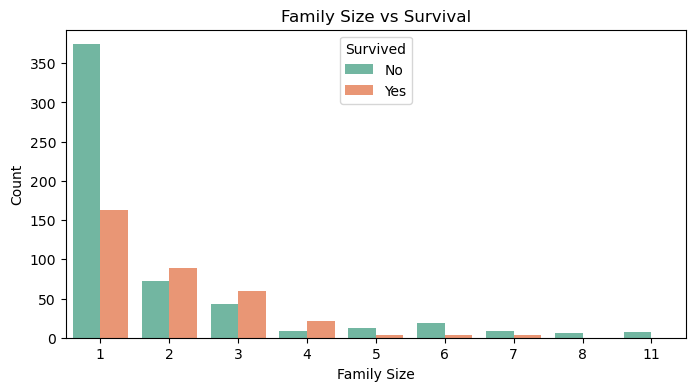

In [14]:
plt.figure(figsize=(8, 4))
sns.countplot(
    x='FamilySize',
    hue='Survived',
    data=train_test,
    palette='Set2'
)
plt.title('Family Size vs Survival')
plt.xlabel('Family Size')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

### 📝 Conclusion — Family Size vs Survival (Count Plot)
Passengers with **family size 2–4** had notably better survival rates compared to solo travelers (size 1) and very large families (7+). Solo travelers had the highest non-survival count. This suggests a "sweet spot" — small family units helped each other evacuate, while solo travelers had no support and large families struggled to coordinate evacuation together.

In [15]:
pd.crosstab(train_test["FamilyType"],train_test["Survived"])

Survived,0.0,1.0
FamilyType,,
Alone,374,163
Double,72,89
Large,52,10
Small,51,80


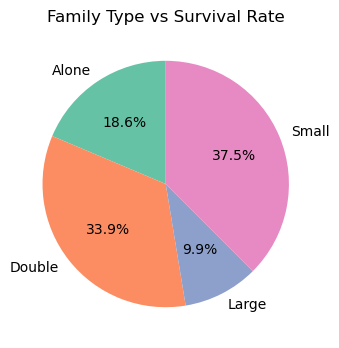

In [16]:
family_survival = train_test.groupby('FamilyType')['Survived'].mean()

plt.figure(figsize=(8, 4))
plt.pie(
    family_survival,
    labels=family_survival.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('Set2', len(family_survival))
)
plt.title('Family Type vs Survival Rate')
plt.show()

### 📝 Conclusion — Family Type vs Survival Rate (Pie Chart)
**Small families** had the highest survival rate, followed by **Double** (2-person groups). Passengers traveling **Alone** had the lowest survival proportion. Large families also fared poorly.

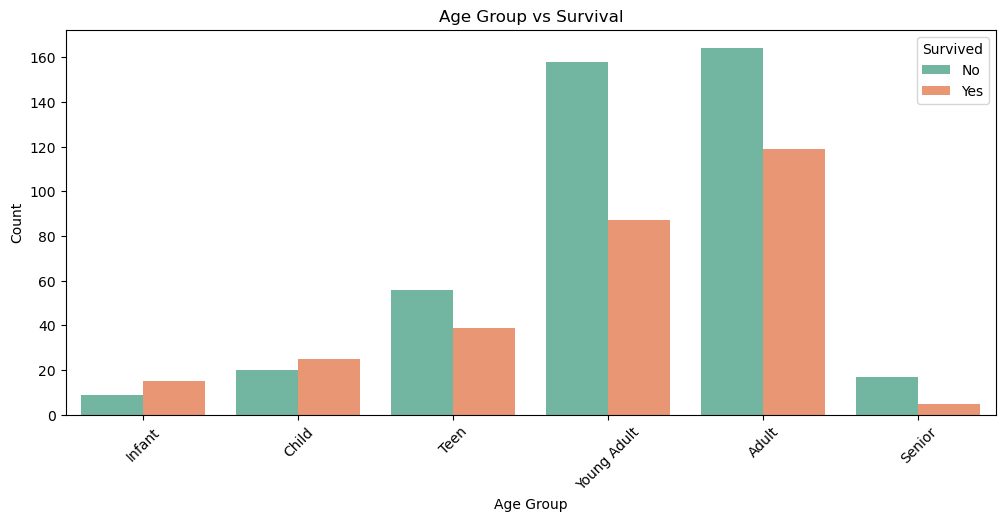

In [17]:
plt.figure(figsize=(12, 5))
sns.countplot(
    x='Age_Group',
    hue='Survived',
    data=train_test,
    palette='Set2'
)
plt.xticks(rotation=45)
plt.title('Age Group vs Survival')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

### 📝 Conclusion — Age Group vs Survival (Count Plot)
**Infants and Children** had relatively higher survival rates compared to their group sizes, reflecting the "women and children first" evacuation policy. **Adults and Young Adults** show the most deaths numerically, partly because they are the largest groups. **Seniors** had poor survival odds. Overall, age was a significant survival factor — younger passengers were prioritized.

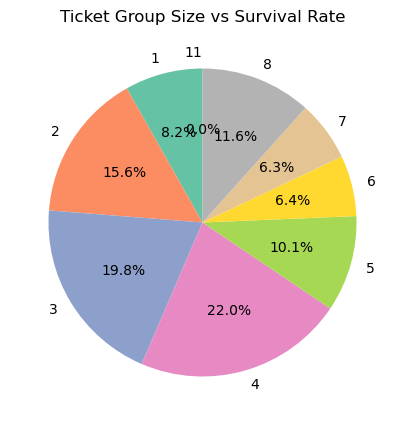

In [18]:
ticket_survival = train_test.groupby('TicketGroupSize')['Survived'].mean()

plt.figure(figsize=(10, 5))
plt.pie(
    ticket_survival,
    labels=ticket_survival.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('Set2', len(ticket_survival))
)
plt.title('Ticket Group Size vs Survival Rate')
plt.show()

### 📝 Conclusion — Ticket Group Size vs Survival Rate (Pie Chart)
Passengers with **medium-sized ticket groups (2–4)** enjoyed higher survival rates compared to solo travelers or very large groups. This mirrors the family size finding — being part of a small coordinated group improved survival odds. Passengers on shared tickets likely stayed together and assisted each other during the evacuation.

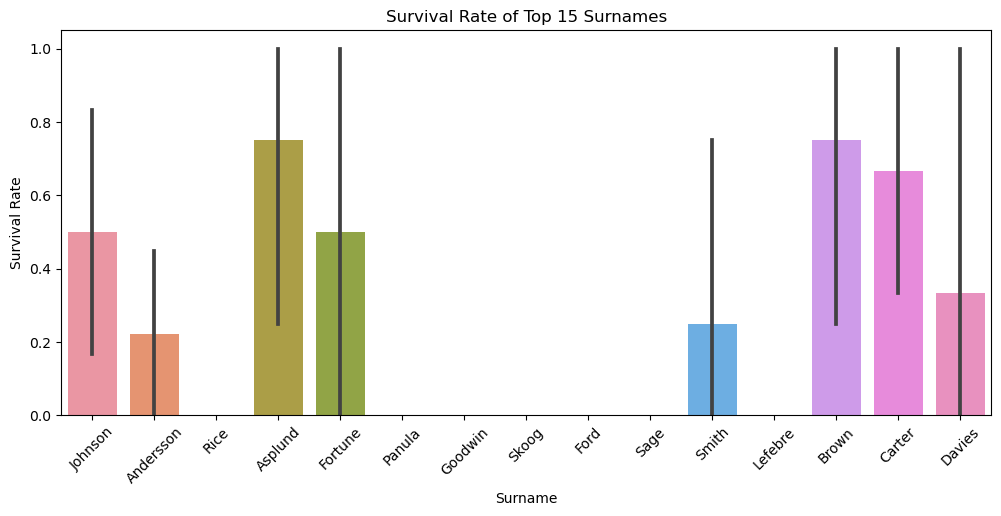

In [19]:
top_surnames = train_test['Surname'].value_counts().head(15).index

plt.figure(figsize=(12,5))

sns.barplot(
    data=train_test[train_test['Surname'].isin(top_surnames)],
    x='Surname',
    y='Survived',
    estimator=lambda x: x.mean()
)

plt.xticks(rotation=45)
plt.title('Survival Rate of Top 15 Surnames')
plt.ylabel('Survival Rate')
plt.show()

### 📝 Conclusion — Survival Rate of Top 15 Surnames (Bar Plot)
Survival rates vary significantly across family surnames, suggesting **family-level survival patterns**. Some families had near-100% survival (likely wealthy 1st-class families or those near lifeboats), while others had very low rates. This highlights how class, cabin location, and social networks within families influenced survival outcomes.

---
## ✅ Bivariate Analysis — Conclusion

Bivariate analysis examined the relationship between each engineered feature and survival:

| Feature vs Survived | Finding |
|--------------------|---------|
| `FamilySize` | Size 2–4 = best survival; Size 1 (solo) and 7+ = worst |
| `FamilyType` | Small families survived most; Alone passengers survived least |
| `Age_Group` | Infants & Children prioritized; Seniors had lowest survival |
| `TicketGroupSize` | Medium group sizes (2–4) had better survival odds |
| `Surname` | Strong family-level survival clusters visible in top 15 surnames |

### 🔍 Key Insights
- A **"sweet spot" family size of 2–4** consistently shows the best survival — small enough to evacuate together, large enough to support each other
- **Traveling alone was dangerous** — no one to assist with finding lifeboats or maintaining calm
- The **"women and children first" policy** is visible in Age Group data — young ages had relatively higher survival rates
- **Family name patterns** reveal that some wealthy families had near-100% survival, pointing to the class advantage
- Ticket group size confirms the family size finding independently — shared tickets in small groups were protective

## 7. Multivariate Analysis <a id='7-multivariate'></a>

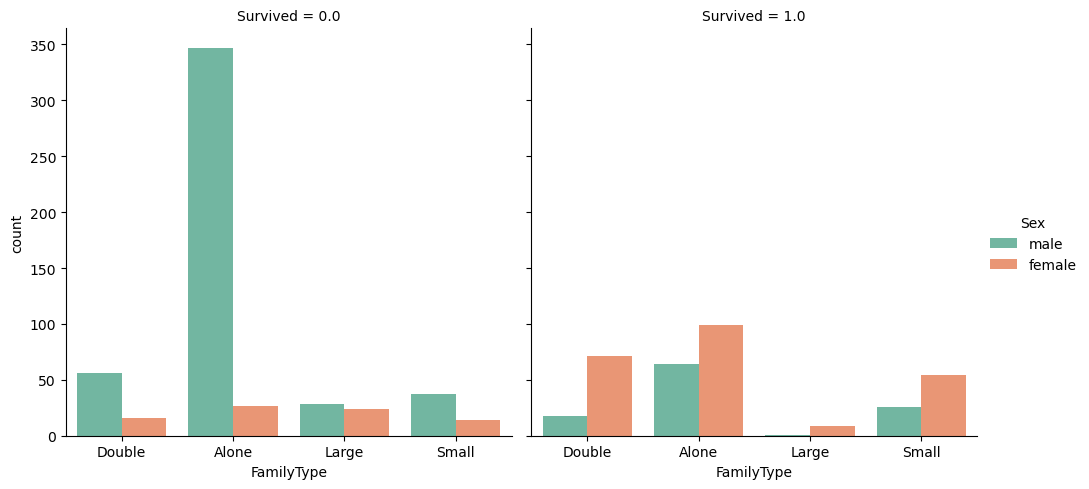

In [20]:
sns.catplot(x='FamilyType', hue='Sex', col='Survived', data=train_test, kind='count', palette='Set2')

### 📝 Conclusion — Family Type × Sex × Survived (Catplot)
**Females survived at much higher rates across all family types**, reinforcing the "women and children first" policy. Among males, those in small families had slightly better odds than solo males. Solo females also survived at high rates. Sex was the dominant factor overriding family structure — being female almost guaranteed a survival advantage regardless of family type.

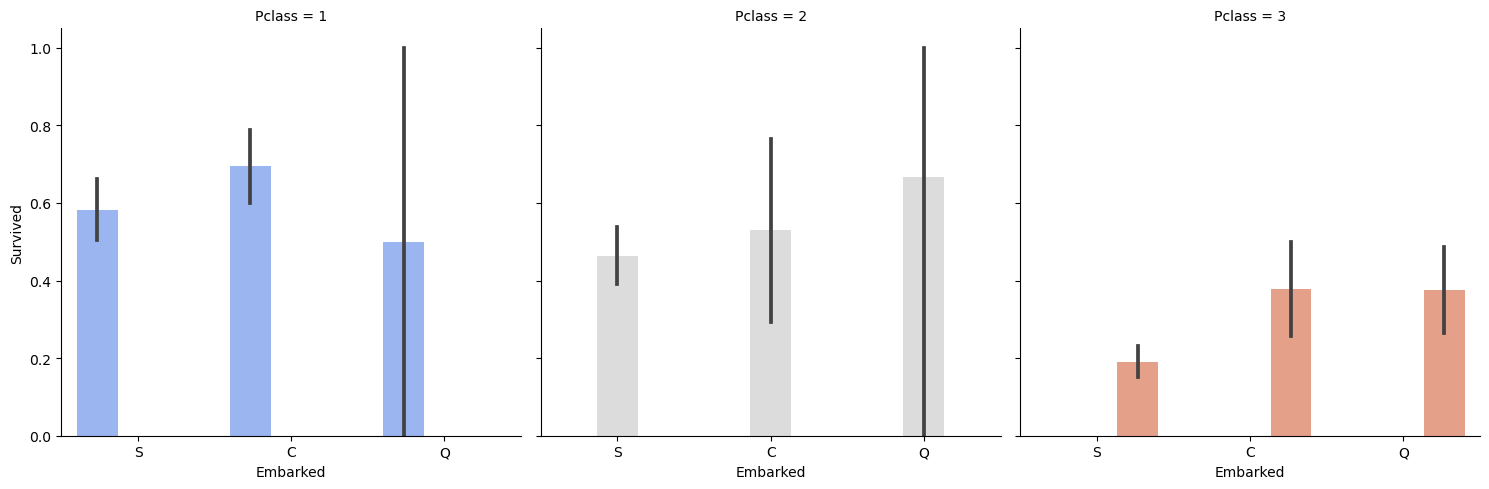

In [21]:
sns.catplot(x='Embarked', y='Survived', hue='Pclass', col='Pclass', data=train_test, kind='bar', palette='coolwarm')

### 📝 Conclusion — Embarked × Pclass × Survived (Catplot)
**1st class passengers survived at higher rates across all embarkation ports**. Southampton (S) had the most 3rd-class passengers with the lowest survival rates. Cherbourg (C) passengers showed higher survival, partly because more 1st-class passengers boarded there. Queenstown (Q) passengers were mostly 3rd class with poor survival. Embarkation port itself is a proxy for passenger class.

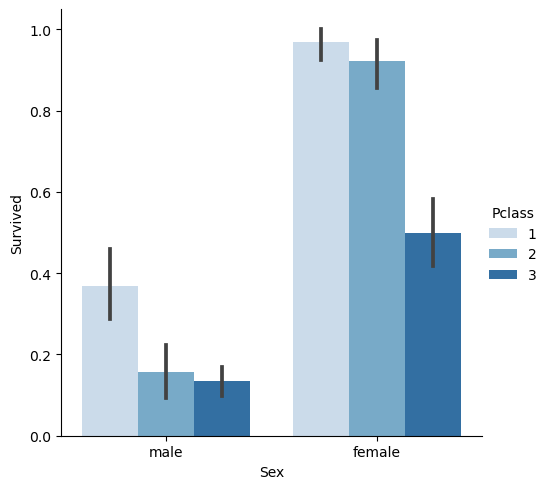

In [22]:
sns.catplot(x='Sex', y='Survived', hue='Pclass', data=train_test, kind='bar', palette='Blues')

### 📝 Conclusion — Sex × Pclass × Survived (Bar Plot)
This is one of the most revealing charts: **female survival was high across all classes**, but especially in 1st and 2nd class (near 90–95%). Male survival was universally lower, with 3rd-class males having the worst odds (~15%). The interaction of sex and class created a clear survival hierarchy: 1st-class females > 2nd-class females > 3rd-class females > 1st-class males > 2nd-class males > 3rd-class males.

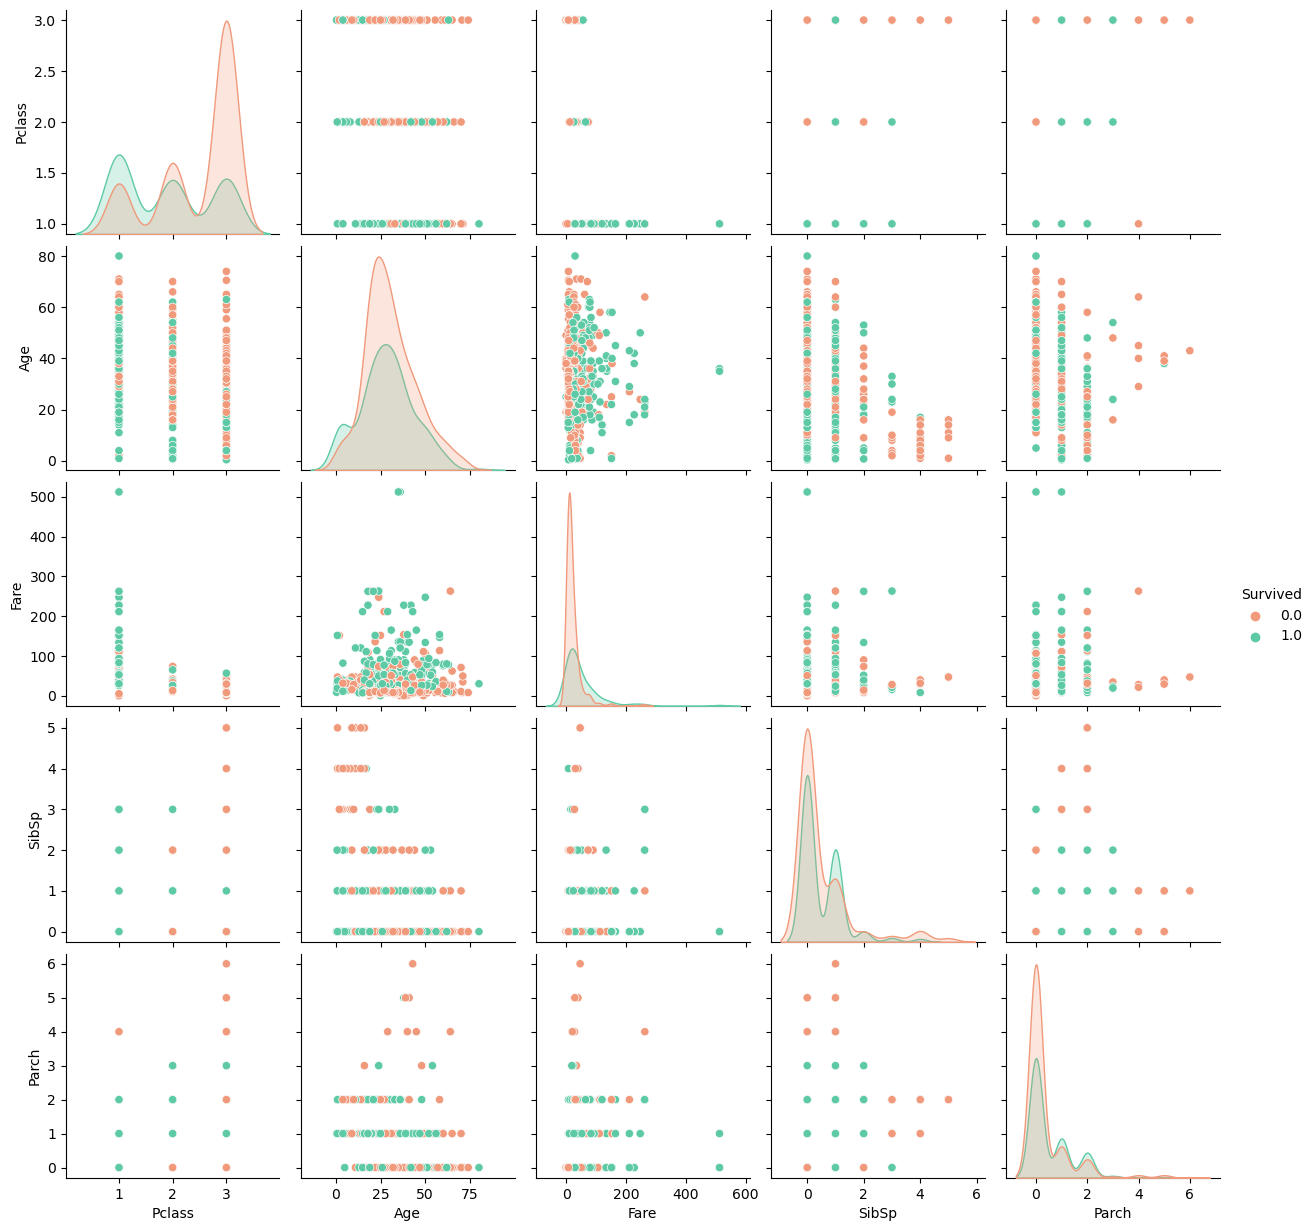

In [23]:
sns.pairplot(train_test[['Survived','Pclass','Age','Fare','SibSp','Parch']].dropna(), hue='Survived', palette={0:'#F0997B', 1:'#5DCAA5'})

### 📝 Conclusion — Pairplot (Survived, Pclass, Age, Fare, SibSp, Parch)
The pairplot reveals several patterns:
- **Fare** shows the clearest separation — survivors (green) tend to have paid higher fares (1st class)
- **Pclass** strongly separates survivors: lower class number = better survival
- **Age** shows younger passengers slightly more likely to survive
- **SibSp and Parch** have weak linear relationships with survival but confirm the family-size effect
- Fare and Pclass are strongly correlated (higher class = higher fare)

In [24]:
pivot = pd.pivot_table(
    df,
    values='Survived',
    index=['Embarked','Sex'],
    columns='Pclass',
    aggfunc='mean'
)

print(pivot)

Pclass                  1         2         3
Embarked Sex                                 
C        female  0.976744  1.000000  0.652174
         male    0.404762  0.200000  0.232558
Q        female  1.000000  1.000000  0.727273
         male    0.000000  0.000000  0.076923
S        female  0.958333  0.910448  0.375000
         male    0.354430  0.154639  0.128302


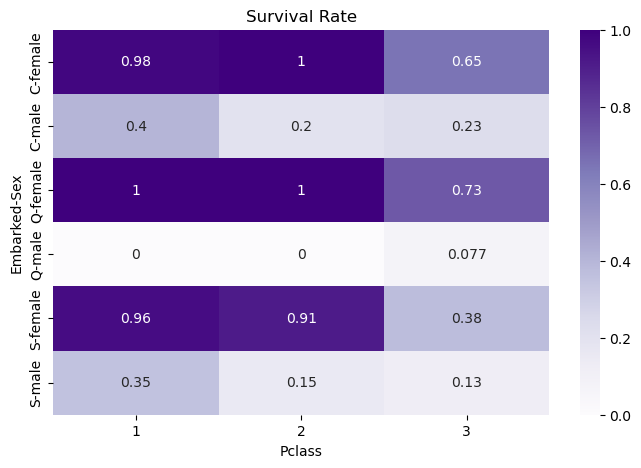

In [25]:
plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, cmap='Purples')
plt.title("Survival Rate")
plt.show()

### 📝 Conclusion — Survival Rate Heatmap (Embarked × Sex × Pclass)
The heatmap confirms the combined effect of gender, class, and embarkation:
- **Female + 1st class** passengers had the highest survival rates (~95%) regardless of embarkation
- **Male + 3rd class** had the lowest survival rates (~10–15%)
- Cherbourg females had exceptionally high rates, reflecting the wealthy 1st-class profile of C-embarkers
- The gradient from top-left (high survival) to bottom-right (low survival) powerfully illustrates how privilege determined fate on the Titanic

## ✅ Multivariate Analysis — Conclusion

Multivariate analysis uncovered how multiple variables interact to determine survival:

| Analysis | Key Finding |
|----------|------------|
| FamilyType × Sex × Survived | Sex dominates — females survived across ALL family types |
| Embarked × Pclass × Survived | Cherbourg (C) = wealthiest passengers = highest survival |
| Sex × Pclass × Survived | Clear hierarchy: 1st-class female → 3rd-class male |
| Pairplot | Fare & Pclass are the clearest survival separators |
| Heatmap (Embarked × Sex × Pclass) | Female + 1st class ≈ 95% survival; Male + 3rd ≈ 10% |

### 🔍 Key Insights
- **Gender is the single strongest survival predictor**, overriding family type, class, and age
- **Class amplifies gender advantage** — 1st-class females had near-certain survival; 3rd-class males had almost no chance
- **Fare and Pclass are highly correlated** — both capture socioeconomic privilege, which translated directly into lifeboat access
- **Embarkation port is a proxy for class** — Cherbourg boarded the wealthiest passengers
- The pairplot confirms **no single numerical feature perfectly separates survivors** — survival required a combination of factors

### 🏆 Survival Hierarchy (Worst → Best)
```
3rd-class male (solo) → 3rd-class female → 2nd-class male → 1st-class male → 2nd-class female → 1st-class female
```

> Multivariate analysis makes it undeniable: **the Titanic disaster was a social catastrophe as much as a physical one** — wealth, gender, and social position determined who lived and who died.

## 8. Data Cleaning — Missing Value Comparison <a id='8-data-cleaning'></a>

In [27]:
def compare_two_columns_fill_visualization(train_test, Age, Survived):

    columns = [Age,Survived]

    for col in columns:

        print(f"\n========== {col} ==========\n")

        # Original Variance
        original_var = train_test[col].var()

        # Mean Fill
        mean_fill = train_test[col].fillna(train_test[col].mean())
        mean_var = mean_fill.var()

        # Median Fill
        median_fill = train_test[col].fillna(train_test[col].median())
        median_var = median_fill.var()

        # Random Fill
        random_fill = train_test[col].copy()

        random_values = train_test[col].dropna().sample(
            train_test[col].isnull().sum(),
            replace=True,
            random_state=42
        )

        random_fill[random_fill.isnull()] = random_values.values
        random_var = random_fill.var()

        # ======================
        # Visualization
        # ======================

        fig, axes = plt.subplots(1, 3, figsize=(18,5))

        sns.histplot(mean_fill, kde=True, ax=axes[0])
        axes[0].set_title(f"{col} - Mean Fill\nVariance = {mean_var:.2f}")

        sns.histplot(median_fill, kde=True, ax=axes[1])
        axes[1].set_title(f"{col} - Median Fill\nVariance = {median_var:.2f}")

        sns.histplot(random_fill, kde=True, ax=axes[2])
        axes[2].set_title(f"{col} - Random Fill\nVariance = {random_var:.2f}")

        plt.tight_layout()
        plt.show()

        # Variance Print
        print("Original Variance :", round(original_var,2))
        print("Mean Fill Variance :", round(mean_var,2))
        print("Median Fill Variance :", round(median_var,2))
        print("Random Fill Variance :", round(random_var,2))


========== Age ==========



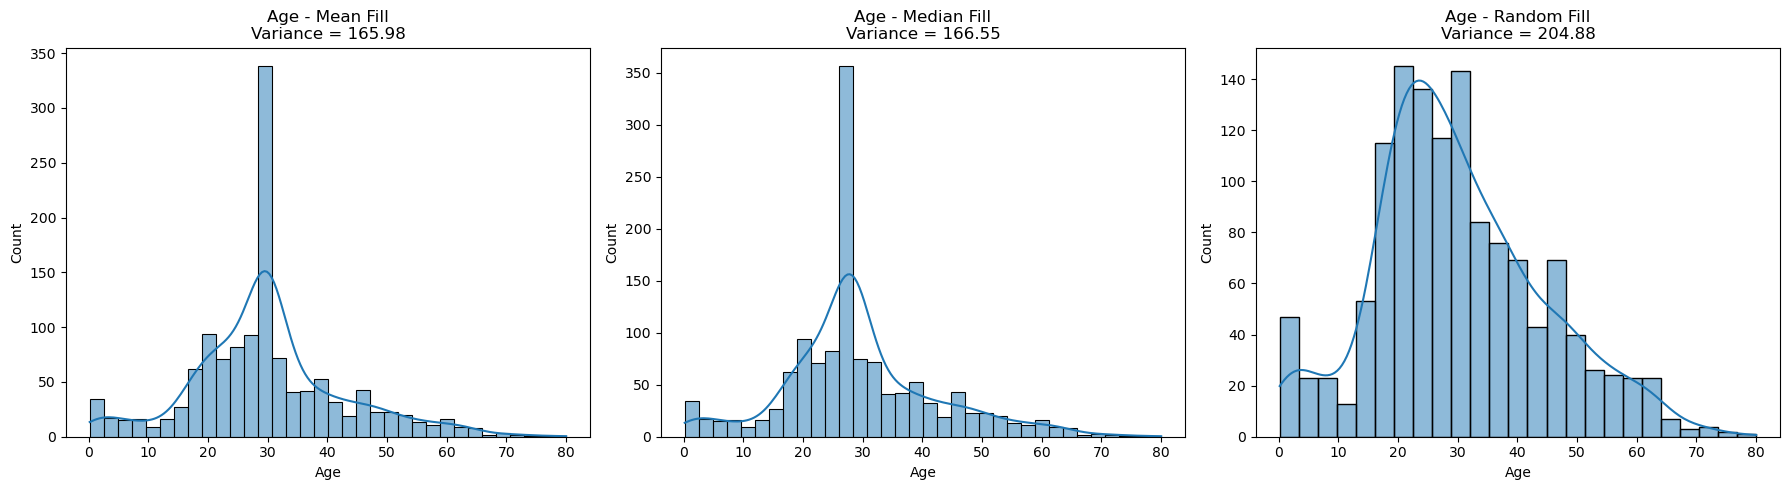

Original Variance : 207.75
Mean Fill Variance : 165.98
Median Fill Variance : 166.55
Random Fill Variance : 204.88

========== Survived ==========



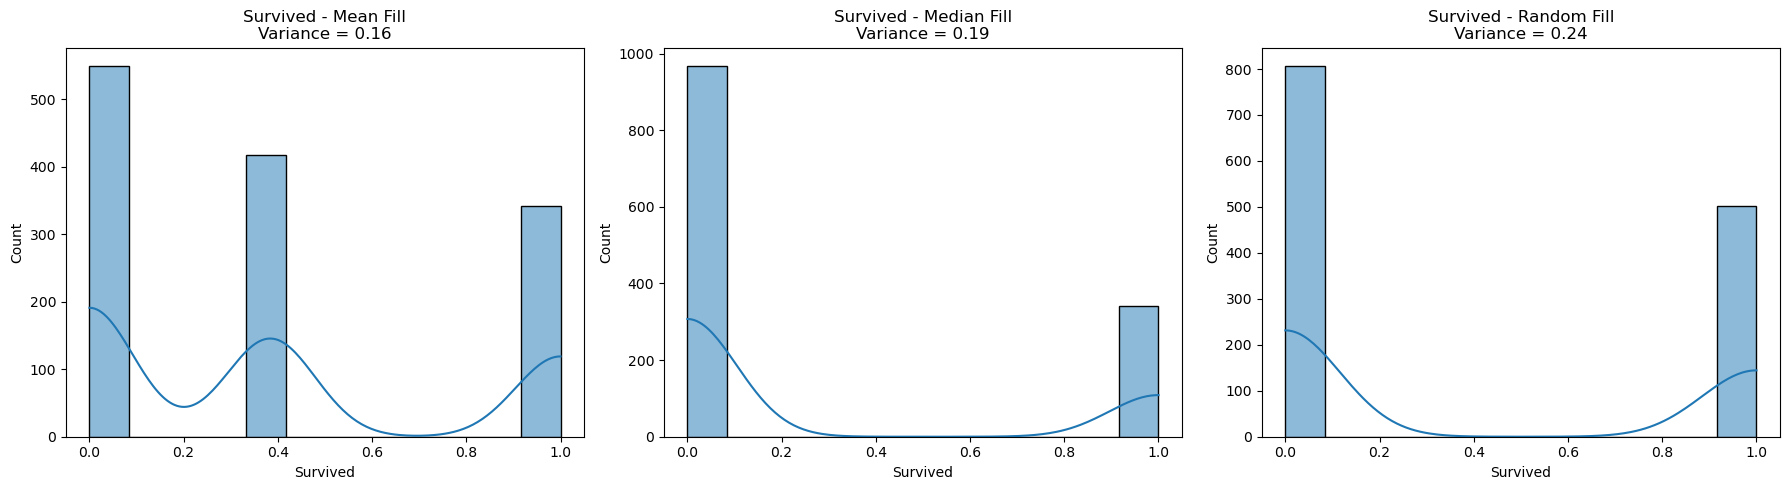

Original Variance : 0.24
Mean Fill Variance : 0.16
Median Fill Variance : 0.19
Random Fill Variance : 0.24


In [28]:
compare_two_columns_fill_visualization(train_test, 'Age', 'Survived')

In [41]:
new_train_test = train_test.copy()


## Age

In [30]:
new_train_test.loc[
    new_train_test['Age'].isnull(),
    'Age'
] = new_train_test['Age'].dropna().sample(
    new_train_test['Age'].isnull().sum(),
    replace=True,
    random_state=42
).values

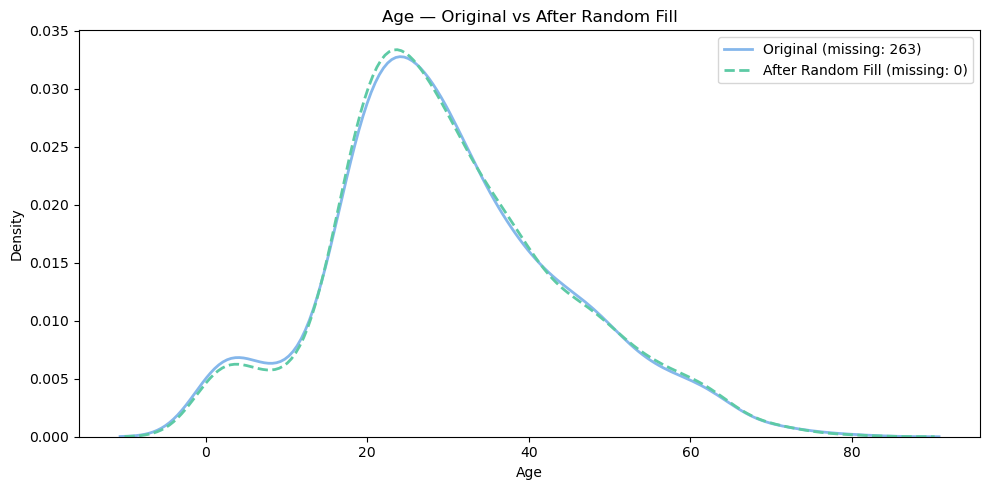

In [31]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.kdeplot(train_test['Age'].dropna(), ax=ax, color='#85B7EB',
            linewidth=2, label=f'Original (missing: {train_test["Age"].isnull().sum()})')

sns.kdeplot(new_train_test['Age'], ax=ax, color='#5DCAA5',
            linewidth=2, linestyle='--', label='After Random Fill (missing: 0)')

ax.set_title('Age — Original vs After Random Fill')
ax.set_xlabel('Age')
ax.legend()
plt.tight_layout()
plt.show()

### 📝 Conclusion — Age: Original vs After Random Fill (KDE Plot)
The **random fill preserved the original Age distribution** almost perfectly — the two KDE curves overlap closely. In contrast, mean/median fill creates artificial spikes at central values, distorting the distribution. Random sampling from observed values is the best imputation strategy for Age, as it maintains variance and realistic shape without introducing bias.

## Embarked

In [32]:
new_train_test['Embarked'].fillna(new_train_test['Embarked'].mode()[0], inplace=True)

In [33]:
new_train_test['Fare'].fillna(new_train_test['Fare'].median(), inplace=True)

In [34]:
bins   = [0, 2, 12, 19, 30, 60, 100]
labels = ['Infant', 'Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
new_train_test['Age_Group'] = pd.cut(
    new_train_test['Age'], bins=bins, labels=labels, right=True)

In [35]:
new_train_test['FarePerPerson'] = (new_train_test['Fare'] / new_train_test['FamilySize'])

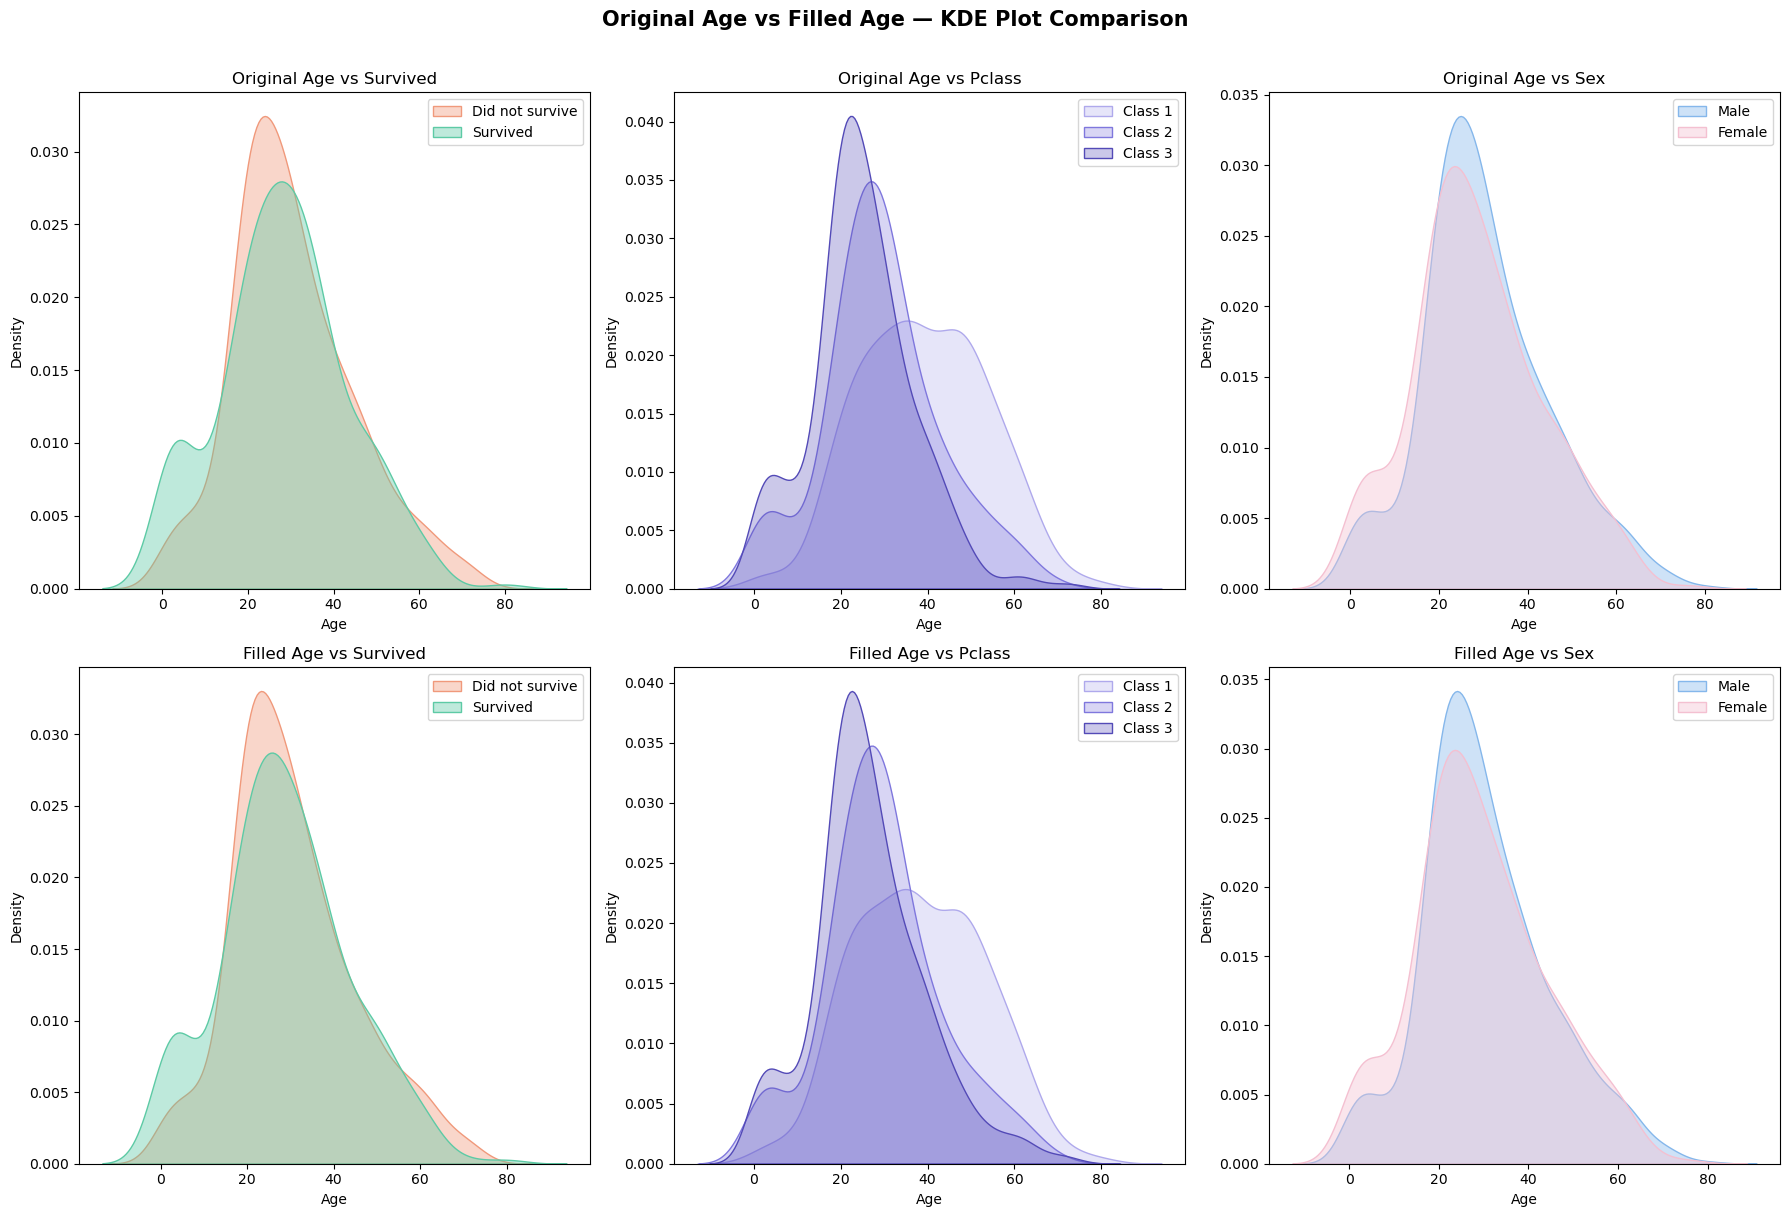

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Age vs Survived — KDE plot
for val, color, label in zip([0, 1], ['#F0997B', '#5DCAA5'], ['Did not survive', 'Survived']):
    sns.kdeplot(train_test[train_test['Survived'] == val]['Age'].dropna(),
                ax=axes[0][0], color=color, fill=True, alpha=0.4, label=label)
axes[0][0].set_title('Original Age vs Survived')
axes[0][0].legend()

for val, color, label in zip([0, 1], ['#F0997B', '#5DCAA5'], ['Did not survive', 'Survived']):
    sns.kdeplot(new_train_test[new_train_test['Survived'] == val]['Age'].dropna(),
                ax=axes[1][0], color=color, fill=True, alpha=0.4, label=label)
axes[1][0].set_title('Filled Age vs Survived')
axes[1][0].legend()

# 2. Age vs Pclass — KDE plot
colors_pclass = ['#AFA9EC', '#7F77DD', '#534AB7']
for pclass, color in zip([1, 2, 3], colors_pclass):
    sns.kdeplot(train_test[train_test['Pclass'] == pclass]['Age'].dropna(),
                ax=axes[0][1], color=color, fill=True, alpha=0.3, label=f'Class {pclass}')
axes[0][1].set_title('Original Age vs Pclass')
axes[0][1].legend()

for pclass, color in zip([1, 2, 3], colors_pclass):
    sns.kdeplot(new_train_test[new_train_test['Pclass'] == pclass]['Age'].dropna(),
                ax=axes[1][1], color=color, fill=True, alpha=0.3, label=f'Class {pclass}')
axes[1][1].set_title('Filled Age vs Pclass')
axes[1][1].legend()

# 3. Age vs Sex — KDE plot
for sex, color in zip(['male', 'female'], ['#85B7EB', '#F4C0D1']):
    sns.kdeplot(train_test[train_test['Sex'] == sex]['Age'].dropna(),
                ax=axes[0][2], color=color, fill=True, alpha=0.4, label=sex.capitalize())
axes[0][2].set_title('Original Age vs Sex')
axes[0][2].legend()

for sex, color in zip(['male', 'female'], ['#85B7EB', '#F4C0D1']):
    sns.kdeplot(new_train_test[new_train_test['Sex'] == sex]['Age'].dropna(),
                ax=axes[1][2], color=color, fill=True, alpha=0.4, label=sex.capitalize())
axes[1][2].set_title('Filled Age vs Sex')
axes[1][2].legend()

plt.suptitle('Original Age vs Filled Age — KDE Plot Comparison',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 📝 Conclusion — Age Fill Comparison: Original vs Filled (6-Panel KDE)
Across all comparisons (Age vs Survived, Age vs Pclass, Age vs Sex), the **filled Age distributions closely mirror the originals**. The survival separation patterns, class-based age differences, and gender distributions are preserved after imputation. This validates that random fill was the correct choice — it does not distort any downstream relationship between Age and other key variables.

## Handleing outliers

## Fare:

In [37]:
def handle_outliers_clip(new_train_test, col):

    nums = new_train_test[col].dropna().tolist()

    if len(nums) < 4:
        print(f"Not enough data points in {col} to calculate quartiles.")
        return new_train_test

    length = len(nums)
    order = sorted(nums)

    # Quartiles Position
    Q1 = (25 * (length + 1)) / 100
    Q2 = (50 * (length + 1)) / 100
    Q3 = (75 * (length + 1)) / 100

    def calculate_quartile(Q):

        if Q != int(Q):
            lower_index = int(Q) - 1
            upper_index = lower_index + 1

            # Safety Check
            if upper_index >= len(order):
                return order[-1]

            fraction = Q - int(Q)

            lower_value = order[lower_index]
            upper_value = order[upper_index]

            return lower_value + (fraction * (upper_value - lower_value))

        else:
            return order[int(Q) - 1]

    # Calculate Quartiles
    q1 = calculate_quartile(Q1)
    q2 = calculate_quartile(Q2)
    q3 = calculate_quartile(Q3)

    # IQR
    iqr = q3 - q1

    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)

    # Outliers Before Clipping
    outliers_before = new_train_test[
        (new_train_test[col] < lower_bound) |
        (new_train_test[col] > upper_bound)
    ][col]

    print("=" * 50)
    print(f"Column : {col}")
    print(f"Q1           : {q1:.2f}")
    print(f"Median (Q2)  : {q2:.2f}")
    print(f"Q3           : {q3:.2f}")
    print(f"IQR          : {iqr:.2f}")
    print(f"Lower Bound  : {lower_bound:.2f}")
    print(f"Upper Bound  : {upper_bound:.2f}")
    print(f"Outliers Before : {len(outliers_before)}")

    # Clip Outliers
    new_train_test[col] = new_train_test[col].clip(
        lower=lower_bound,
        upper=upper_bound
    )

    # Outliers After Clipping
    outliers_after = new_train_test[
        (new_train_test[col] < lower_bound) |
        (new_train_test[col] > upper_bound)
    ][col]

    print(f"Outliers After  : {len(outliers_after)}")
    print("=" * 50)

    return new_train_test

In [43]:
handle_outliers_clip(new_train_test, 'Fare').head(2)

Column : Fare
Q1           : 7.90
Median (Q2)  : 14.45
Q3           : 31.27
IQR          : 23.38
Lower Bound  : -27.17
Upper Bound  : 66.34
Outliers Before : 0
Outliers After  : 0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,FamilyType,FarePerPerson,NameTitle,Surname,FamilyGroup,TicketGroupSize,Age_Group
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,Double,3.62,Mr,Braund,Braund_A/5 21171,1,Young Adult
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,66.3438,C85,C,2,Double,35.64,Mrs,Cumings,Cumings_PC 17599,2,Adult


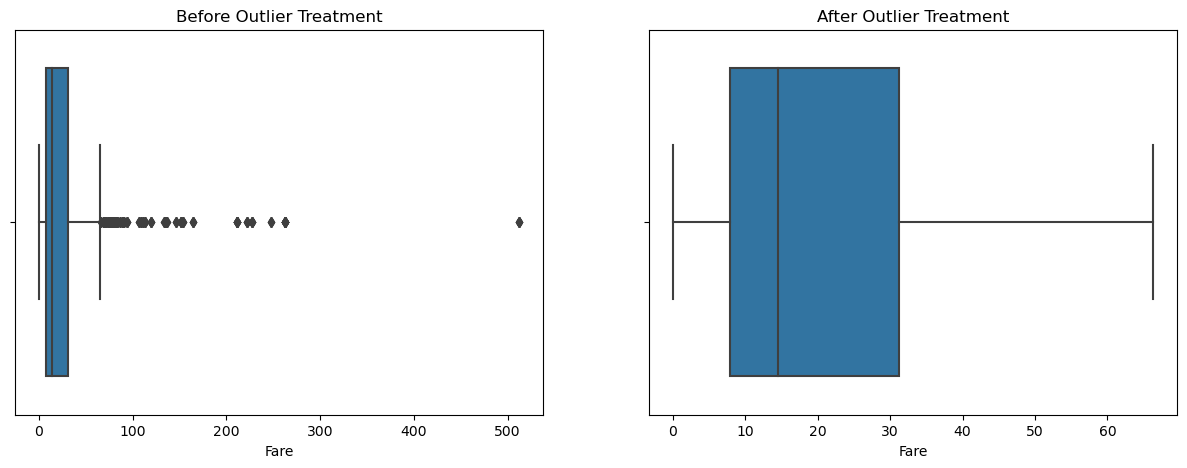

In [39]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
sns.boxplot(x=train_test['Fare'])
plt.title('Before Outlier Treatment')

plt.subplot(1,2,2)
sns.boxplot(x=new_train_test['Fare'])
plt.title('After Outlier Treatment')

plt.show()

### 📝 Conclusion — Fare Outlier Treatment (Box Plot: Before vs After)
Before treatment, Fare had **extreme outliers** (passengers paying 500+ for luxury suites), causing a heavily right-skewed distribution. After IQR-based clipping, the distribution is much more compact and the box plot whiskers are normalized. Outlier treatment prevents these extreme fares from disproportionately influencing machine learning models or statistical summaries.

In [40]:
new_train_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   PassengerId      1309 non-null   int64   
 1   Survived         891 non-null    float64 
 2   Pclass           1309 non-null   int64   
 3   Name             1309 non-null   object  
 4   Sex              1309 non-null   object  
 5   Age              1309 non-null   float64 
 6   SibSp            1309 non-null   int64   
 7   Parch            1309 non-null   int64   
 8   Ticket           1309 non-null   object  
 9   Fare             1309 non-null   float64 
 10  Cabin            295 non-null    object  
 11  Embarked         1309 non-null   object  
 12  FamilySize       1309 non-null   int64   
 13  FamilyType       1309 non-null   object  
 14  FarePerPerson    1309 non-null   float64 
 15  NameTitle        1309 non-null   object  
 16  Surname          1309 non-null   object  


 ## 🏁 Overall Conclusion — Titanic EDA

This exploratory data analysis reveals the key factors that determined survival aboard the Titanic:

### 🔑 Key Findings

| Factor | Insight |
|--------|---------|
| **Gender** | The strongest predictor — females survived at ~74% vs ~19% for males ("women and children first" policy was real) |
| **Passenger Class** | 1st class had ~63% survival, 2nd class ~47%, 3rd class only ~24% — wealth = access to lifeboats |
| **Age** | Children (especially infants) were prioritized; seniors had poor survival odds |
| **Family Size** | Small families (2–4 members) survived best; solo travelers and large families fared worst |
| **Fare** | Higher-paying passengers (1st class) were physically closer to lifeboats and had better access |
| **Embarkation Port** | Cherbourg passengers survived best — a proxy for higher class composition |

### 🔗 Combined Effects
The most dangerous profile: **3rd-class solo male traveler from Southampton** — lowest survival probability.  
The safest profile: **1st-class female in a small family from Cherbourg** — near-certain survival.

### 🛠️ Data Quality Actions Taken
- **Age** (20% missing): Filled using random sampling to preserve distribution shape ✅
- **Fare** (1 missing): Filled with median ✅  
- **Embarked** (2 missing): Filled with mode (Southampton) ✅  
- **Cabin** (77%+ missing): Not used — too sparse to be reliable ✅  
- **Fare outliers**: Clipped using IQR method to prevent model distortion ✅

### 📌 Features Most Useful for Modeling
Based on this EDA, the top features for a survival prediction model would be:  
`Sex`, `Pclass`, `Age` (filled), `FamilySize`, `FarePerPerson`, `Embarked`, `FamilyType`

> *"The Titanic disaster was not random — survival was systematically structured by gender, wealth, and social position."*
